<a href="https://colab.research.google.com/github/shamimos/K--Nearest-Neighbors-KNN-/blob/main/EA2_K_Nearest_Neighbors_(KNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EA2. K- Nearest Neighbors (KNN)

Nombre: Shara Milena Mosquera Goez. Grupo: PREICA2501B010106

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [ ]:
resumen_estadistico = df.describe()

print(resumen_estadistico)

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [ ]:
churn_counts = df['Churn'].value_counts()

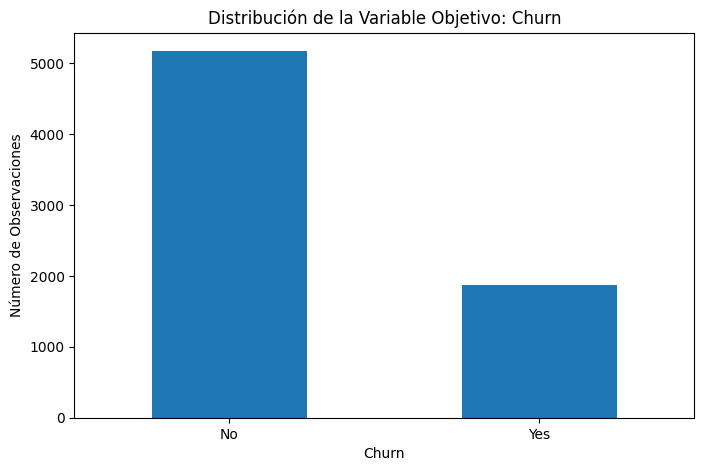

In [ ]:
# Crear el gráfico de barras
plt.figure(figsize=(8, 5))
churn_counts.plot(kind='bar')
plt.title('Distribución de la Variable Objetivo: Churn')
plt.xlabel('Churn')
plt.ylabel('Número de Observaciones')
plt.xticks(rotation=0)  # Mantiene las etiquetas de los ejes x horizontales
plt.show()

La gráfica muestra la distribución de la variable "Churn", indicando que la mayoría de los clientes continúan usando el servicio ("No") y una minoría ha dejado de usarlo ("Yes"). Esto refleja una alta tasa de retención de clientes. Sería beneficioso investigar las causas del churn para mejorar aún más las estrategias de retención.

In [ ]:
import seaborn as sns
# Lista de variables categóricas a analizar
categorical_vars = ['gender', 'InternetService']


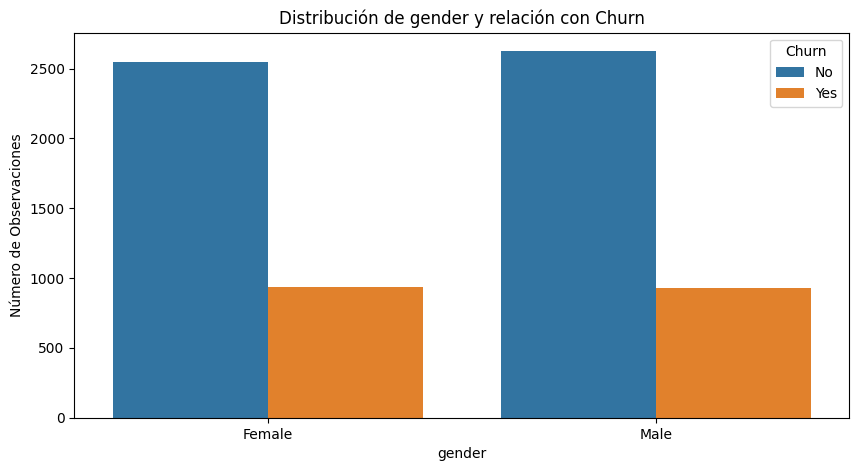

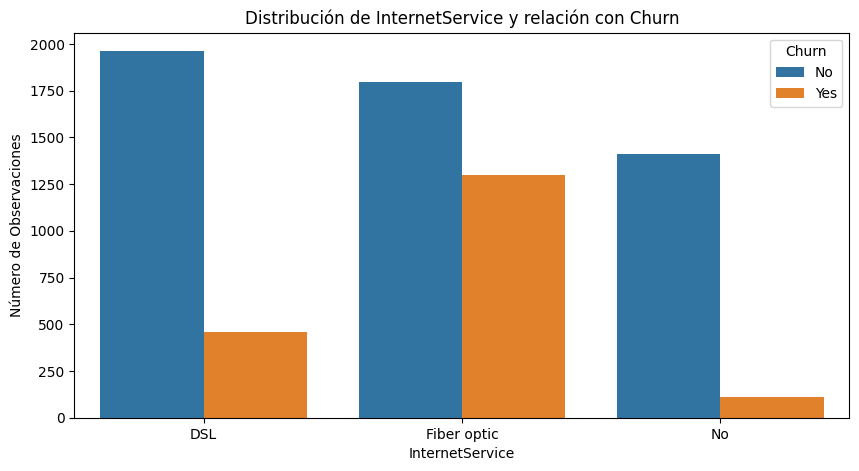

In [ ]:
# Crear gráficos para cada variable categórica
for var in categorical_vars:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=var, hue='Churn', data=df)
    plt.title(f'Distribución de {var} y relación con Churn')
    plt.xlabel(var)
    plt.ylabel('Número de Observaciones')
    plt.legend(title='Churn', loc='upper right')
    plt.show()

**Distribución de género y relación con Churn:** Esta gráfica muestra que tanto hombres como mujeres tienen tasas de churn similares, indicando que el género no tiene un impacto significativo en la probabilidad de churn.

**Distribución de Internet Service y relación con Churn:** Esta gráfica muestra la distribución del churn según el tipo de servicio de internet proporcionado. Observamos que los clientes con servicio de fibra óptica tienen una tasa de churn más alta en comparación con los que tienen DSL y aquellos sin servicio. Esto podría sugerir que, aunque la fibra óptica es probablemente una opción tecnológicamente superior, puede haber factores como el costo, la fiabilidad o la satisfacción del cliente que contribuyen a una mayor tasa de churn.

In [ ]:
# Selecciona solo columnas numéricas para la correlación
numeric_df = df.select_dtypes(include=['float64', 'int64'])

In [ ]:
# Calcula la matriz de correlación solo con las columnas numéricas
correlation_matrix = numeric_df.corr()

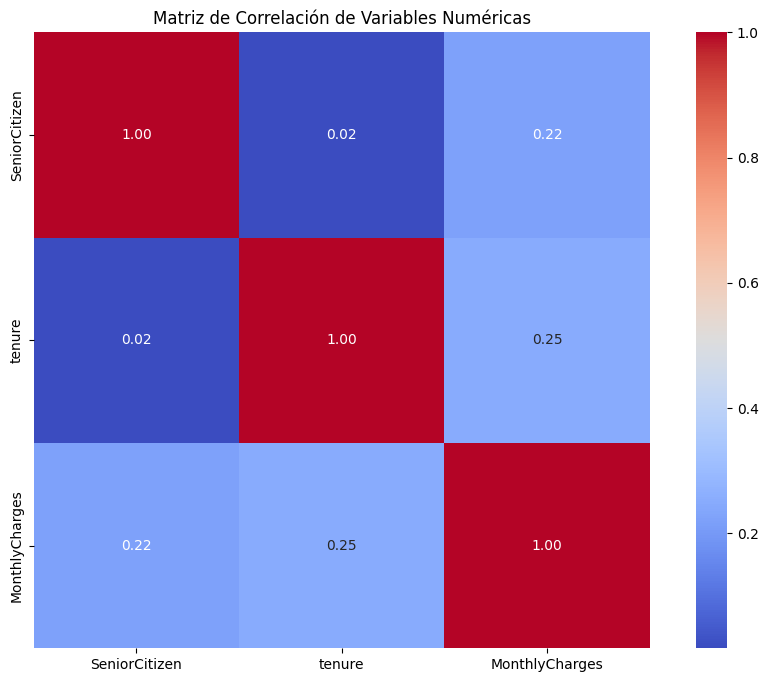

In [ ]:
# Visualiza la matriz de correlación usando un heatmap de seaborn
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

La matriz de correlación muestra que las correlaciones entre ser un ciudadano senior, la duración del servicio (tenure) y los cargos mensuales (MonthlyCharges) son generalmente bajas, lo que indica que estas variables no están fuertemente relacionadas entre sí.

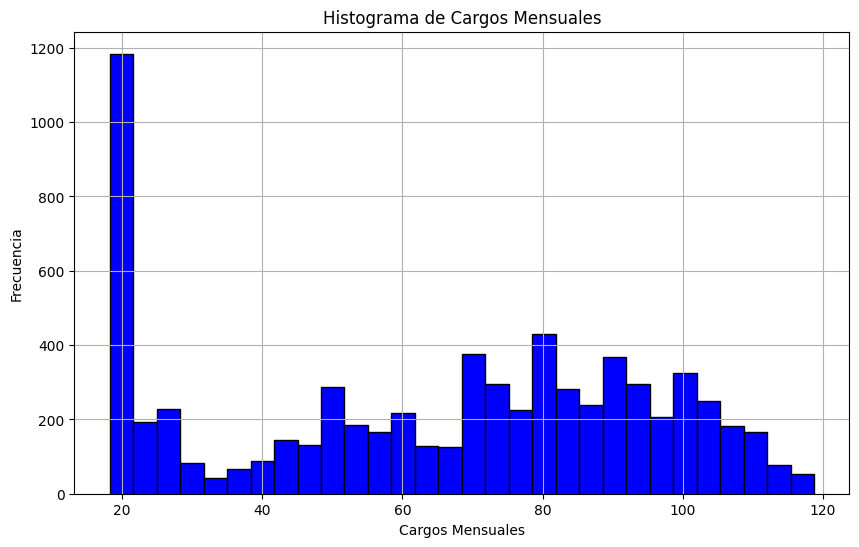

In [ ]:
# Suponiendo que 'df' es tu DataFrame y que contiene una columna 'income'
plt.figure(figsize=(10, 6))
plt.hist(df['MonthlyCharges'], bins=30, color='blue', edgecolor='black')
plt.title('Histograma de Cargos Mensuales')
plt.xlabel('Cargos Mensuales')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

El histograma de cargos mensuales muestra una amplia gama de montos que los clientes pagan por un servicio, con un pico dominante alrededor de los 20 dólares y varios picos menores a lo largo del rango hasta 120 dólares. Esta distribución indica que la mayoría de los clientes opta por un plan básico económico, mientras que otros seleccionan planes más costosos o añaden servicios adicionales.

La estandarización de datos es crucial en análisis y modelado porque reduce la influencia de outliers y asegura que todas las características contribuyan equitativamente al proceso de análisis. Este proceso transforma los datos para tener una media de 0 y desviación estándar de 1, mejorando la convergencia de algoritmos que dependen de gradientes y facilitando la comparabilidad entre variables. Es especialmente útil en técnicas estadísticas y modelos de aprendizaje automático que asumen una distribución normal de los datos.

In [ ]:
from sklearn.preprocessing import StandardScaler

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')  # Convertir a numérico, coercing errores
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())  # Rellenar valores NaN con la mediana

In [ ]:
# Inicializar el StandardScaler
scaler = StandardScaler()

In [ ]:
# Columnas para escalar
columns_to_scale = ['MonthlyCharges', 'TotalCharges']
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])
# Verificar los cambios
print(df[columns_to_scale].head())

   MonthlyCharges  TotalCharges
0       -1.160323     -0.994242
1       -0.259629     -0.173244
2       -0.362660     -0.959674
3       -0.746535     -0.194766
4        0.197365     -0.940470


In [ ]:
from sklearn.model_selection import train_test_split
# Características (todas las columnas menos 'Churn')
X = df.drop(['Churn', 'customerID'], axis=1)
# Aplicar One-Hot Encoding a todo el DataFrame para manejar todas las columnas categóricas
X = pd.get_dummies(X)
# Variable objetivo
y = df['Churn']
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
print("Training set (X_train):", X_train.shape)
print("Test set (X_test):", X_test.shape)
print("Training target (y_train):", y_train.shape)
print("Test target (y_test):", y_test.shape)

Training set (X_train): (4930, 45)
Test set (X_test): (2113, 45)
Training target (y_train): (4930,)
Test target (y_test): (2113,)


In [ ]:
#Verificación de la Transformación
print(X.head())

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Female  \
0              0       1       -1.160323     -0.994242           True   
1              0      34       -0.259629     -0.173244          False   
2              0       2       -0.362660     -0.959674          False   
3              0      45       -0.746535     -0.194766          False   
4              0       2        0.197365     -0.940470           True   

   gender_Male  Partner_No  Partner_Yes  Dependents_No  Dependents_Yes  ...  \
0        False       False         True           True           False  ...   
1         True        True        False           True           False  ...   
2         True        True        False           True           False  ...   
3         True        True        False           True           False  ...   
4        False        True        False           True           False  ...   

   StreamingMovies_Yes  Contract_Month-to-month  Contract_One year  \
0               

In [ ]:
#Crear una Instancia del Clasificador
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)

In [ ]:
#Entrenar al clasificador
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
from sklearn.metrics import accuracy_score
# Evaluación del modelo
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Precisión del clasificador KNN:", accuracy)

Precisión del clasificador KNN: 0.7666824420255561


In [ ]:
# Lista para almacenar las precisiones
accuracies = []

# Rango de número de vecinos a probar
neighbors_range = range(1, 26)  # Por ejemplo, de 1 a 25 vecinos

for n_neighbors in neighbors_range:
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

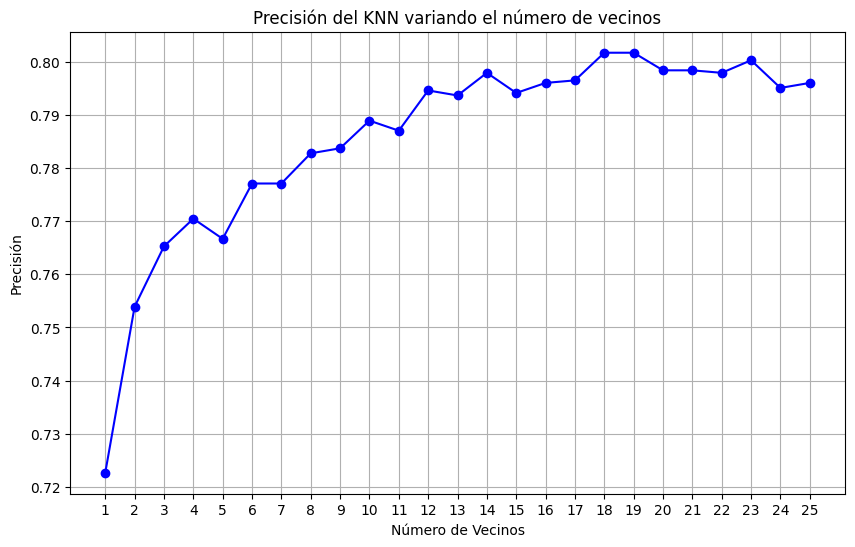

In [ ]:
# Visualizar los resultados
plt.figure(figsize=(10, 6))
plt.plot(neighbors_range, accuracies, marker='o', linestyle='-', color='b')
plt.title('Precisión del KNN variando el número de vecinos')
plt.xlabel('Número de Vecinos')
plt.ylabel('Precisión')
plt.xticks(neighbors_range)  # Asegura que todos los valores de vecinos aparezcan en el eje x
plt.grid(True)
plt.show()

La gráfica muestra cómo la precisión del algoritmo K-Nearest Neighbors (KNN) cambia al ajustar el número de vecinos. Inicialmente, con un solo vecino, la precisión es baja, pero mejora significativamente al aumentar el número de vecinos hasta estabilizarse entre 10 y 25 vecinos. Esto indica que un número moderado de vecinos, aproximadamente entre 10 y 15, ofrece un buen equilibrio entre precisión y eficiencia, proporcionando una precisión estable sin ser excesivamente sensible al ruido en los datos. Este análisis ayuda a identificar el número óptimo de vecinos para usar en la implementación del algoritmo KNN para maximizar la precisión.